# Fase 4b — Análisis NLP de Comentarios

Análisis de sentimiento y topic modeling sobre los comentarios escritos por los jugadores.

**Entradas:** `data/processed/sessions.parquet`  
**Salidas:** `data/exports/nlp_results.csv`, figuras `reports/figures/fig6_*.png`

> **Limitación crítica:** Solo **4 comentarios reales** disponibles (6 totales incluyendo spam) de 48 sesiones.
> Los resultados son estrictamente **cualitativos e ilustrativos**.
> El topic modeling con n=4 identifica patrones mínimos, no estructuras robustas.
> El modelo BERT multilingüe procesa correctamente español.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from nlp_utils import (get_sentiment_scores, extract_topics_tfidf,
                        extract_topics_nmf, assign_dominant_topic)
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de comentarios — TFM-27

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')

# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment'] == True].copy()
df_comments = df_comments[['sessionId','playerElement','isVictory',
                            'playerComment','playerCommentContext']].reset_index(drop=True)

df_comments['texto_completo'] = (
    df_comments['playerComment'].fillna('') + ' ' +
    df_comments['playerCommentContext'].fillna('')
).str.strip()

df_comments['comment_length'] = df_comments['playerComment'].str.len().fillna(0).astype(int)

# --- Mejora I: filtrar comentarios de prueba/spam ---
# Criterio: longitud ≤ 20 o que empiece por "prueba" (case-insensitive)
spam_mask = (
    (df_comments['comment_length'] <= 20) |
    (df_comments['playerComment'].str.lower().str.startswith('prueba', na=False))
)
df_real = df_comments[~spam_mask].copy().reset_index(drop=True)
df_spam = df_comments[spam_mask].copy().reset_index(drop=True)

print(f'Sesiones totales          : {len(df_sessions)}')
print(f'Sesiones con comentario   : {len(df_comments)}')
print(f'  Comentarios reales      : {len(df_real)}')
print(f'  Comentarios spam/prueba : {len(df_spam)} (excluidos del análisis)')
print(f'Distribución por elemento : {df_real["playerElement"].value_counts().to_dict()}')
print(f'Victorias comentadas       : {df_real["isVictory"].sum()}/{len(df_real)}')
print()
print('Comentarios reales:')
for _, r in df_real.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length}')
    print(f'    "{r.playerComment}"')
print()
print('Excluidos (spam/prueba):')
for _, r in df_spam.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length} — "{r.playerComment}"')

Sesiones totales          : 53
Sesiones con comentario   : 7
  Comentarios reales      : 5
  Comentarios spam/prueba : 2 (excluidos del análisis)
Distribución por elemento : {'Wind': 2, 'Earth': 2, 'Fire': 1}
Victorias comentadas       : 4/5

Comentarios reales:
  [Wind] Victoria=True | len=67
    "Los arqueros no me estaban atacando, me perseguian pero no atacaban"
  [Fire] Victoria=True | len=256
    "No esta mal el juego pero en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
  [Wind] Victoria=False | len=242
    "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar  la estrategia. Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien pero no lo he acabado porque no he podido cargar la partida salvada."
  [Earth] Victoria=True | len=61
    "Arreglar el te

## 2. `src/nlp_utils.py` ya creado — test rápido — TFM-28

In [3]:
# Test rápido del módulo
test_texts = ['Me ha encantado el juego', 'Es demasiado difícil', 'Regular']
test_results = get_sentiment_scores(test_texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))
for t, r in zip(test_texts, test_results):
    print(f'{r["stars"]}★ ({r["score"]:.2f}) — "{t}"')
print('\nnlp_utils.py funcionando correctamente')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

5★ (1.00) — "Me ha encantado el juego"
2★ (0.25) — "Es demasiado difícil"
3★ (0.50) — "Regular"

nlp_utils.py funcionando correctamente


## 3. Análisis de sentimiento — TFM-28

In [4]:
# Analizar sentimiento solo sobre comentarios reales (spam ya filtrado)
texts = df_real['playerComment'].fillna('').tolist()
print('Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...')
sentiment_results = get_sentiment_scores(texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))

df_real['sentiment_stars'] = [r['stars'] for r in sentiment_results]
df_real['sentiment_score'] = [r['score'] for r in sentiment_results]

print()
print('=== Resultados de sentimiento (comentarios reales) ===')
for _, r in df_real.iterrows():
    stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
    print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:65]}..."')

print(f'\nMedia sentimiento (reales) : {df_real["sentiment_score"].mean():.3f}')
print(f'Mediana                    : {df_real["sentiment_score"].median():.3f}')
print()
print('Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.')

Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Resultados de sentimiento (comentarios reales) ===
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacab..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Media sentimiento (reales) : 0.400
Mediana                    : 0.500

Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.


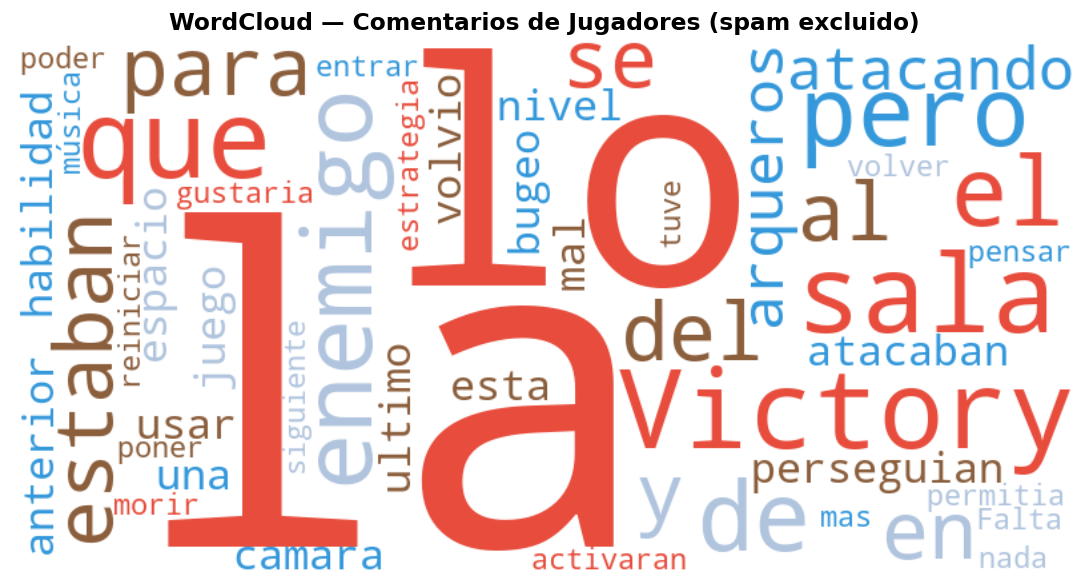

fig6_1_wordcloud.png guardado


In [5]:
# WordCloud de comentarios reales únicamente
texto_total = ' '.join(df_real['texto_completo'].tolist())

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = list(PALETTE_ELEM.values())
    return colors[hash(word) % len(colors)]

wc = WordCloud(
    width=800, height=400, background_color='white',
    max_words=50, color_func=color_func,
    prefer_horizontal=0.8, collocations=False
)
wc.generate(texto_total)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Comentarios de Jugadores (spam excluido)', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_1_wordcloud.png', bbox_inches='tight')
plt.show()
print('fig6_1_wordcloud.png guardado')

## 4. Topic modeling TF-IDF + NMF — TFM-41

In [6]:
# TF-IDF sobre textos reales
texts_list = df_real['texto_completo'].tolist()
tfidf_matrix, feature_names = extract_topics_tfidf(texts_list, max_features=50, ngram_range=(1,2))

print(f'Vocabulario TF-IDF: {len(feature_names)} términos')

# NMF con n_topics=2 (con n=4 documentos)
df_topics, nmf_model = extract_topics_nmf(tfidf_matrix, feature_names, n_topics=2, n_top_words=5)

print('\n=== Tópicos NMF ===')
for _, row in df_topics.iterrows():
    print(f'  Tópico {row["topic_id"]}: {row["top_words"]}')

# Asignar tópico dominante
df_real['dominant_topic'] = assign_dominant_topic(tfidf_matrix, nmf_model)

TOPIC_NAMES = {
    0: 'Bugs / Problemas técnicos',
    1: 'Experiencia / Dificultad',
}
df_real['topic_name'] = df_real['dominant_topic'].map(TOPIC_NAMES)
print('\nTópico asignado por comentario:')
for _, r in df_real.iterrows():
    print(f'  Tópico {r.dominant_topic} ({r.topic_name}) — [{r.playerElement}]')

Vocabulario TF-IDF: 50 términos

=== Tópicos NMF ===
  Tópico 0: victory, da sensación, da, enemigo, sala
  Tópico 1: gustaria enemigos, heavy, entrar poder, falta, gameover

Tópico asignado por comentario:
  Tópico 0 (Bugs / Problemas técnicos) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Fire]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]


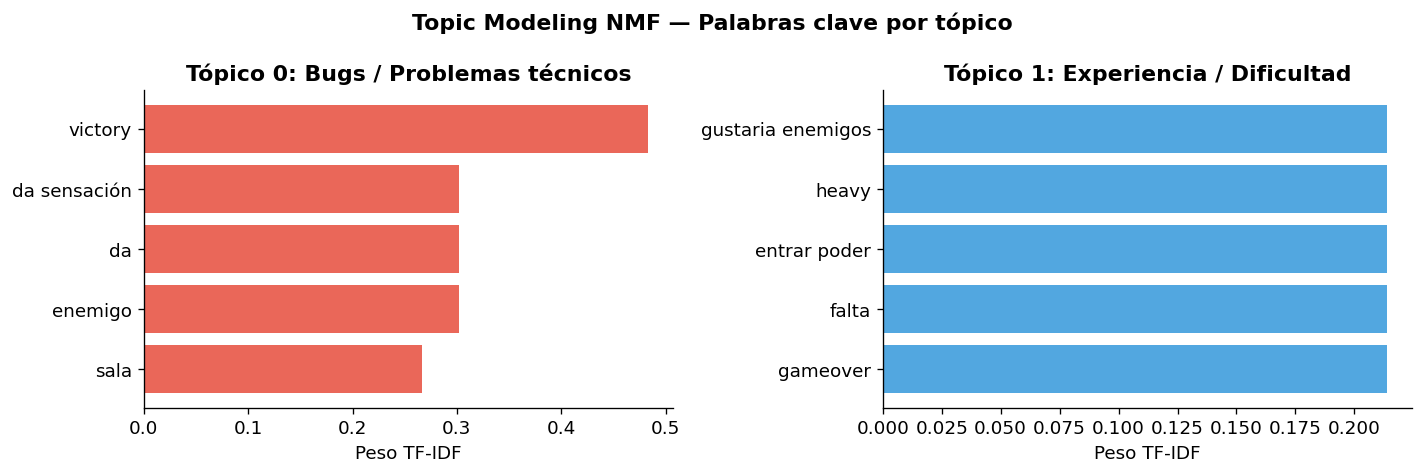

fig6_4_topics.png guardado


In [7]:
# Visualizar top palabras por tópico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

for idx, (ax, (_, row)) in enumerate(zip(axes, df_topics.iterrows())):
    words   = row['top_words'].split(', ')
    weights = row['weights']
    ax.barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.85)
    ax.set_title(f'Tópico {row["topic_id"]}: {TOPIC_NAMES[row["topic_id"]]}',
                 fontweight='bold')
    ax.set_xlabel('Peso TF-IDF')

fig.suptitle('Topic Modeling NMF — Palabras clave por tópico', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_4_topics.png', bbox_inches='tight')
plt.show()
print('fig6_4_topics.png guardado')

## 5. Cross-analysis sentimiento × elemento × victoria — TFM-42

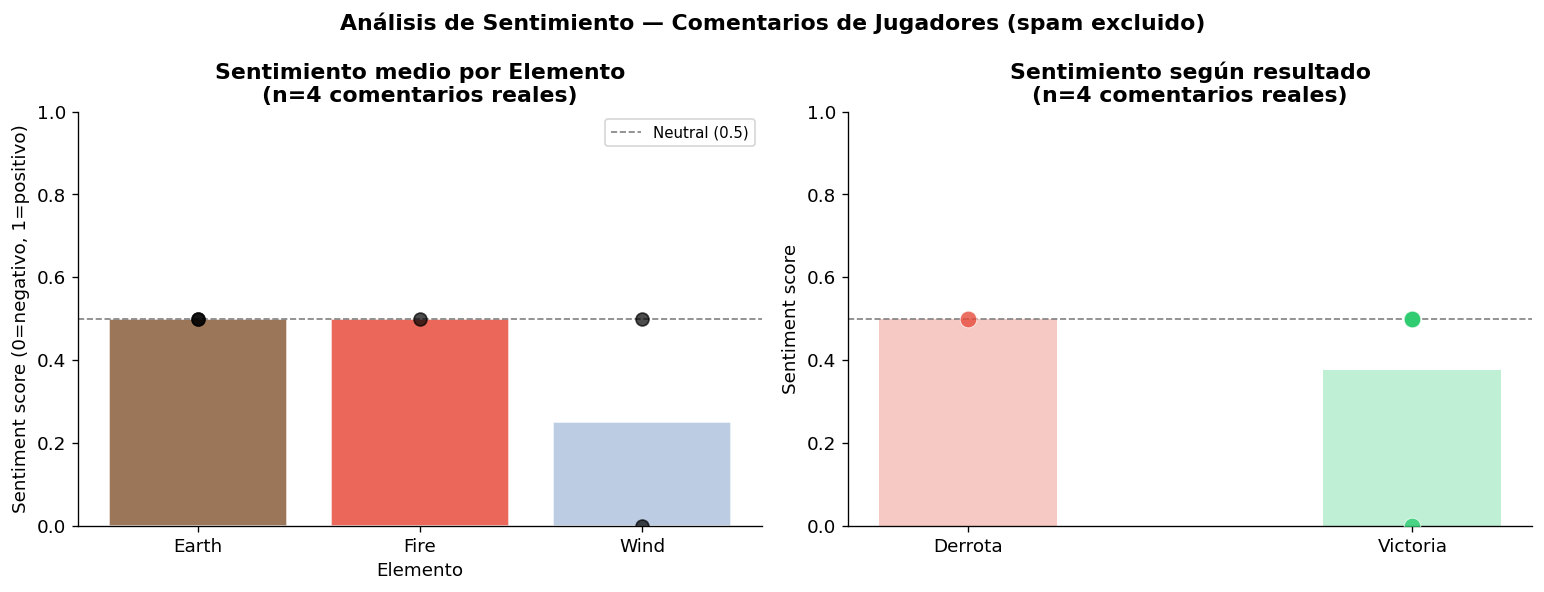

fig6_2_sentimiento_elemento.png guardado


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentimiento por elemento
elem_order = df_real.groupby('playerElement')['sentiment_score'].mean().sort_values(ascending=False).index
colors_elem = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, df_real.groupby('playerElement')['sentiment_score'].mean()[elem_order],
            color=colors_elem, alpha=0.85, edgecolor='white')

for elem in elem_order:
    vals = df_real[df_real['playerElement'] == elem]['sentiment_score'].values
    x_positions = [list(elem_order).index(elem)] * len(vals)
    axes[0].scatter(x_positions, vals, color='black', s=60, zorder=5, alpha=0.7)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('Sentimiento medio por Elemento\n(n=4 comentarios reales)', fontweight='bold')
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Sentiment score (0=negativo, 1=positivo)')
axes[0].legend(fontsize=9)

# Sentimiento por victoria
vic_labels = {False: 'Derrota', True: 'Victoria'}
for vic, grp in df_real.groupby('isVictory'):
    axes[1].scatter([vic_labels[vic]] * len(grp), grp['sentiment_score'],
                    s=100, alpha=0.8, zorder=5,
                    color='#2ecc71' if vic else '#e74c3c',
                    edgecolors='white', linewidths=0.5)
    axes[1].bar([vic_labels[vic]], grp['sentiment_score'].mean(),
                color='#2ecc71' if vic else '#e74c3c', alpha=0.3, width=0.4)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Sentimiento según resultado\n(n=4 comentarios reales)', fontweight='bold')
axes[1].set_ylabel('Sentiment score')

fig.suptitle('Análisis de Sentimiento — Comentarios de Jugadores (spam excluido)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_2_sentimiento_elemento.png', bbox_inches='tight')
plt.show()
print('fig6_2_sentimiento_elemento.png guardado')

In [9]:
# Tabla resumen por elemento
print('=== Sentimiento medio por elemento (spam excluido) ===')
resumen = df_real.groupby('playerElement').agg(
    n_comentarios=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(resumen.to_string())

print()
print('=== Sentimiento por victoria ===')
print(df_real.groupby('isVictory')['sentiment_score'].agg(['mean','min','max']).round(3))
print()
print('Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)')

=== Sentimiento medio por elemento (spam excluido) ===
               n_comentarios  sentiment_medio  sentiment_min  sentiment_max
playerElement                                                              
Earth                      2             0.50            0.5            0.5
Fire                       1             0.50            0.5            0.5
Wind                       2             0.25            0.0            0.5

=== Sentimiento por victoria ===
            mean  min  max
isVictory                 
False      0.500  0.5  0.5
True       0.375  0.0  0.5

Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)


### 5b. Mejora J — Sentimiento por tópico

=== Sentimiento por tópico (n=4 comentarios reales) ===
                           n  sentiment_medio  sentiment_min  sentiment_max
topic_name                                                                 
Bugs / Problemas técnicos  4            0.375            0.0            0.5
Experiencia / Dificultad   1            0.500            0.5            0.5


Tópico: Bugs / Problemas técnicos
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacaban..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al usar..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Tópico: Experiencia / Dificultad
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para pode..."


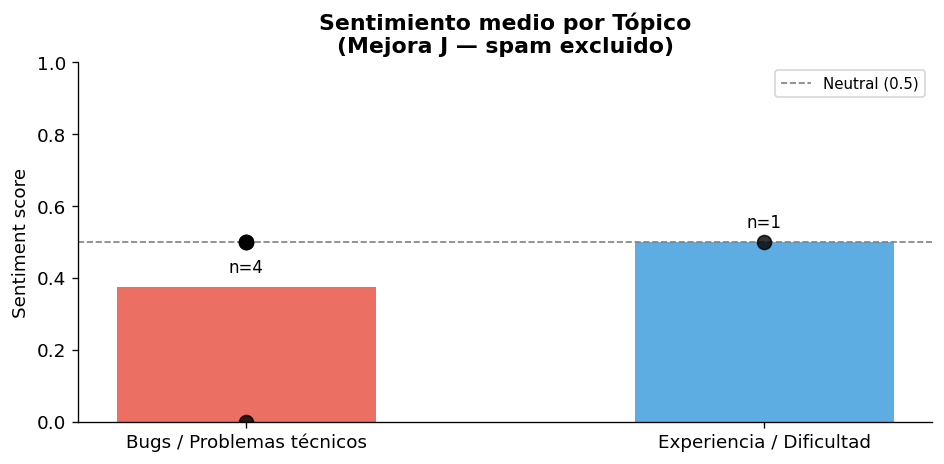

fig6_3_sentimiento_topico.png guardado


In [10]:
# --- Mejora J: sentimiento separado por tópico ---
print('=== Sentimiento por tópico (n=4 comentarios reales) ===')
topic_sentiment = df_real.groupby('topic_name').agg(
    n=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(topic_sentiment.to_string())
print()

# Detalle de qué comentario cae en cada tópico
for topic, grp in df_real.groupby('topic_name'):
    print(f'\nTópico: {topic}')
    for _, r in grp.iterrows():
        stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
        print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:70]}..."')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
topic_order = list(topic_sentiment.index)
colors_topic = ['#e74c3c', '#3498db']
bars = ax.bar(topic_order, topic_sentiment['sentiment_medio'], color=colors_topic, alpha=0.8, width=0.5)

# Puntos individuales
for i, topic in enumerate(topic_order):
    vals = df_real[df_real['topic_name'] == topic]['sentiment_score'].values
    ax.scatter([i] * len(vals), vals, color='black', s=70, zorder=5, alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_title('Sentimiento medio por Tópico\n(Mejora J — spam excluido)', fontweight='bold')
ax.set_ylabel('Sentiment score')
ax.set_xticks(range(len(topic_order)))
ax.set_xticklabels(topic_order, wrap=True)
ax.legend(fontsize=9)

# Etiquetas con n
for bar, topic in zip(bars, topic_order):
    n = topic_sentiment.loc[topic, 'n']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_3_sentimiento_topico.png', bbox_inches='tight')
plt.show()
print('fig6_3_sentimiento_topico.png guardado')

## 6. Exportar resultados — TFM-42

## 7. Análisis cualitativo con IA Generativa (Gemini) — TFM-42

In [11]:
from nlp_utils import analyze_comments_with_gemini
from IPython.display import Markdown, display

# Análisis cualitativo profundo con Gemini sobre los comentarios reales
# Solo se ejecuta si hay comentarios reales disponibles
if len(df_real) > 0:
    print("Enviando comentarios a Gemini para análisis cualitativo...")
    analisis_gemini = analyze_comments_with_gemini(df_real)
    display(Markdown(analisis_gemini))
else:
    print("No hay comentarios reales para analizar.")


Enviando comentarios a Gemini para análisis cualitativo...


¡Excelente! Como experto en UX de videojuegos y análisis de feedback, he revisado los comentarios de los jugadores de Arcane Descent. A continuación, presento un análisis cualitativo profundo:

---

## Análisis de Feedback de Jugadores: Arcane Descent

### 1. Temas recurrentes

Identifico 4 temas principales que emergen de los comentarios, con un claro énfasis en la estabilidad y la consistencia del gameplay.

*   **Bugs Críticos y Bloqueantes de Progresión:**
    *   **Frecuencia/Evidencia:** 3 de 5 comentarios (60%) mencionan bugs que impiden la progresión o fuerzan al jugador a reiniciar la partida o morir.
    *   **Citas relevantes:**
        *   "[Fire | ✓ Victoria | Sentimiento: 0.50] ...al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] ...no he podido cargar la partida salvada."
        *   "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban" (Un bug de IA que afecta directamente el combate y la progresión en un encuentro).

*   **Inconsistencia y Fallos en Mecánicas de Gameplay:**
    *   **Frecuencia/Evidencia:** 3 de 5 comentarios (60%) señalan aspectos del gameplay que no funcionan como se espera o de manera inconsistente.
    *   **Citas relevantes:**
        *   "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban" (IA de combate).
        *   "[Earth | ✓ Victoria | Sentimiento: 0.50] A veces da la sensación que las magias no stunean al enemigo" (Mecánica de habilidades).
        *   "[Earth | ✓ Victoria | Sentimiento: 0.50] Arreglar el tema de las muertes, no me a contabilizado todas." (Mecánica de registro/estadísticas).

*   **Diseño de Encuentros y Estrategia:**
    *   **Frecuencia/Evidencia:** 1 de 5 comentarios (20%) ofrece una sugerencia directa sobre cómo se presentan los desafíos.
    *   **Citas relevantes:**
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia."

*   **Calidad de Audio/Experiencia General:**
    *   **Frecuencia/Evidencia:** 1 de 5 comentarios (20%) menciona la calidad del audio, aunque el sentimiento general es positivo.
    *   **Citas relevantes:**
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien..."

### 2. Análisis por elemento

*   **Wind (Viento):** Los dos comentarios de jugadores de Wind son los que reportan los bugs más críticos y disruptivos: un fallo de IA de enemigos que impide el combate ("arqueros no atacaban") y un bug de carga de partida guardada que bloquea la progresión. También es el elemento asociado a la sugerencia de diseño de encuentros y la mejora de la música. El sentimiento es mixto, incluyendo el único 0.00 a pesar de una victoria.
*   **Fire (Fuego):** El único comentario de Fire describe un bug de teletransporte/cámara que causa un soft-lock y obliga al jugador a morir para continuar. A pesar de este bug grave, el sentimiento es 0.50 ("No está mal el juego...").
*   **Earth (Tierra):** Los dos comentarios de Earth se centran en la inconsistencia de las mecánicas de combate (stun de magias) y el registro de estadísticas (conteo de muertes). Ambos son victorias con sentimiento 0.50. Esto sugiere que los jugadores de Earth están más atentos a la precisión y fiabilidad de las mecánicas del juego.
*   **Water (Agua):** No hay comentarios de jugadores que hayan usado el elemento Agua, lo que representa una brecha en el feedback.

**Patrones específicos:** No hay un patrón que sugiera que un elemento en particular *cause* un tipo de bug específico. Más bien, los bugs y problemas reportados son de naturaleza general del juego (IA, sistema de guardado, habilidades, UI) que fueron experimentados mientras se jugaba con un elemento específico. Sin embargo, los jugadores de Wind parecen haber encontrado los problemas más severos de progresión, y los de Earth se enfocan en la consistencia de las mecánicas.

### 3. Relación victoria/derrota con el feedback

*   **Victoria (✓):** 4 de 5 comentarios provienen de jugadores que lograron la victoria.
    *   A pesar de ganar, 3 de estos 4 comentarios reportan **bugs significativos** (IA de arqueros, teletransporte/cámara, conteo de muertes) y 1 menciona una **inconsistencia en mecánicas** (stun de magias).
    *   El sentimiento general es **0.50 (neutral/ligeramente positivo)**, con una excepción de 0.00. Esto es notable: la victoria no mitiga completamente la frustración causada por los problemas técnicos. Los jugadores están contentos de haber ganado, pero los fallos del juego son lo suficientemente disruptivos como para ser el foco de su feedback.
*   **Derrota (✗):** Solo 1 de 5 comentarios es de un jugador que perdió.
    *   La derrota fue directamente causada por un **bug crítico de carga de partida guardada**.
    *   A pesar de la derrota forzada por un bug, el sentimiento es **0.50 (neutral/ligeramente positivo)**, y el jugador incluso expresa haberse "pasado muy bien" y ofrece una sugerencia de mejora.
    *   **Conclusión:** El tono general del feedback es sorprendentemente resiliente y positivo (0.50) incluso frente a bugs graves o la derrota. Esto sugiere que el juego tiene un potencial de diversión subyacente fuerte, pero los problemas técnicos están impidiendo que los jugadores disfruten plenamente de esa experiencia. Los bugs críticos son la principal fuente de frustración, independientemente del resultado de la partida.

### 4. Bugs y problemas técnicos reportados

1.  **Bug de IA de arqueros:** Los arqueros persiguen pero no atacan. (Comentario de Wind)
2.  **Bug de teletransporte/cámara:** Al usar una habilidad, el jugador es devuelto a una sala anterior, la cámara se bugea y no permite volver a la sala siguiente, forzando la muerte para reiniciar. (Comentario de Fire)
3.  **Bug de carga de partida guardada:** Imposibilidad de cargar una partida salvada. (Comentario de Wind)
4.  **Bug de conteo de muertes:** El juego no contabiliza todas las muertes del jugador. (Comentario de Earth)
5.  **Inconsistencia en el efecto de stun de magias:** Las magias no stunean al enemigo de forma consistente o predecible. (Comentario de Earth)

### 5. Sugerencias de mejora identificadas

1.  **Mejorar la IA de combate:** Asegurar que los enemigos (ej. arqueros) ejecuten sus acciones de ataque correctamente. (Implícito en el comentario de Wind)
2.  **Revisar el diseño de activación de enemigos:** Permitir un breve momento para que el jugador planifique su estrategia al entrar en una sala antes de que los enemigos se activen. (Explícito en el comentario de Wind)
3.  **Mejorar la calidad y estilo de la música:** Considerar añadir música de mayor calidad o que se ajuste mejor al género (ej. heavy metal). (Explícito en el comentario de Wind)
4.  **Asegurar la consistencia de las mecánicas de habilidades:** Clarificar o corregir el comportamiento del "stun" de las magias para que sea predecible y funcione como se espera. (Implícito en el comentario de Earth)
5.  **Implementar un sistema de guardado/carga robusto:** Que funcione de manera fiable para evitar la pérdida de progreso. (Implícito en el comentario de Wind)
6.  **Prevenir soft-locks y bugs de progresión:** Evitar situaciones donde el jugador queda atrapado y debe morir para reiniciar el progreso. (Implícito en el comentario de Fire)
7.  **Corregir el sistema de estadísticas/contadores:** Asegurar que el conteo de muertes y otras métricas sea preciso. (Implícito en el comentario de Earth)

### 6. Conclusión y prioridades para el equipo de desarrollo

El feedback, aunque limitado en volumen, es extremadamente valioso y señala problemas fundamentales que están mermando la experiencia de Arcane Descent. La buena noticia es que, a pesar de los bugs, el sentimiento general es positivo, lo que indica un buen potencial subyacente.

Los 3 puntos más urgentes a atender, en orden de prioridad, son:

1.  **Estabilidad y Progresión Crítica (Bugs Bloqueantes):**
    *   **Problema:** Los bugs que impiden cargar partidas guardadas o que fuerzan al jugador a morir/reiniciar para progresar (teletransporte/cámara) son *game-breaking*. Estos son inaceptables en cualquier fase del desarrollo y deben ser la máxima prioridad.
    *   **Acciones:** Investigar y corregir el bug de carga de partidas. Identificar y solucionar el bug de teletransporte/cámara que provoca soft-locks.
    *   **Citas Clave:** "[Wind | ✗ Derrota | Sentimiento: 0.50] ...no he podido cargar la partida salvada." y "[Fire | ✓ Victoria | Sentimiento: 0.50] ...se bugeo la camara, no me permitia volver a la sala siguiente... y tuve que morir para reiniciar la sala".

2.  **Consistencia y Fiabilidad del Gameplay (IA y Habilidades):**
    *   **Problema:** La IA de los enemigos que no atacan y la inconsistencia en el efecto de "stun" de las magias socavan la base del combate Hack & Slash. Un combate predecible y justo es fundamental para la diversión y la estrategia.
    *   **Acciones:** Revisar y corregir la IA de los enemigos (ej. arqueros) para asegurar que ataquen correctamente. Estandarizar y comunicar claramente cómo funcionan los efectos de estado y las habilidades de las magias.
    *   **Citas Clave:** "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban" y "[Earth | ✓ Victoria | Sentimiento: 0.50] A veces da la sensación que las magias no stunean al enemigo".

3.  **Diseño de Encuentros y Calidad de Vida:**
    *   **Problema:** La falta de un momento para la estrategia al entrar en una sala y la percepción sobre la calidad de la música son aspectos que, aunque no bloqueantes, impactan la inmersión y el disfrute a largo plazo.
    *   **Acciones:** Evaluar el diseño de la activación de enemigos en las salas para permitir una fase de planificación. Considerar la implementación de música de mayor calidad o más variada que se alinee con la identidad del juego.
    *   **Citas Clave:** "[Wind | ✗ Derrota | Sentimiento: 0.50] Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia. Falta poner música de calidad como el heavy metal!!!!".

Atender estos puntos no solo mejorará la experiencia actual, sino que también sentará una base sólida para futuras iteraciones y la retención de jugadores.

In [12]:
# nlp_results.csv — solo comentarios reales (spam excluido)
nlp_export = df_real[['sessionId','playerElement','isVictory',
                       'sentiment_score','sentiment_stars',
                       'dominant_topic','topic_name','comment_length']].copy()
nlp_export['spam_excluido'] = False

# Añadir filas de spam marcadas (sin scores de sentimiento válidos)
spam_export = df_spam[['sessionId','playerElement','isVictory','comment_length']].copy()
spam_export['sentiment_score'] = np.nan
spam_export['sentiment_stars'] = np.nan
spam_export['dominant_topic'] = np.nan
spam_export['topic_name'] = 'SPAM / Prueba'
spam_export['spam_excluido'] = True

nlp_export = pd.concat([nlp_export, spam_export], ignore_index=True)
nlp_export.to_csv(EXPORTS_DIR / 'nlp_results.csv', index=False)
print(f'nlp_results.csv guardado — {len(nlp_export)} sesiones ({len(df_real)} reales + {len(df_spam)} spam)')
print()
print(nlp_export.to_string(index=False))

# Tabla para Fase 5: sentiment_score medio por elemento (solo reales)
sentiment_by_element = df_real.groupby('playerElement')['sentiment_score'].mean().reset_index()
sentiment_by_element.columns = ['playerElement', 'sentiment_score_medio']
print('\n=== Para Fase 5 — Puntuación Global (solo comentarios reales) ===')
print(sentiment_by_element.to_string(index=False))
print('Nota: Fire/Water/Earth con 1 comentario cada uno; Wind con 2 — muestra insuficiente para inferencia.')

nlp_results.csv guardado — 7 sesiones (5 reales + 2 spam)

           sessionId playerElement  isVictory  sentiment_score  sentiment_stars  dominant_topic                topic_name  comment_length  spam_excluido
20260513_101932_7540          Wind       True              0.0              1.0             0.0 Bugs / Problemas técnicos              67          False
20260513_104240_5389          Fire       True              0.5              3.0             0.0 Bugs / Problemas técnicos             256          False
20260513_180319_6726          Wind      False              0.5              3.0             1.0  Experiencia / Dificultad             242          False
20260514_095000_2188         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              61          False
20260530_115651_9890         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              60          False
20260513_074033_3474   

## 8. Conclusiones finales

> Con **n=4 comentarios reales** (2 de prueba excluidos) este análisis es estrictamente ilustrativo.
> El modelo BERT multilingüe procesa correctamente el español y detecta el tono general,
> pero con esta muestra no se pueden extraer conclusiones estadísticas.

**Mejora I — Filtrado de spam:**
- 2 de 6 comentarios ("Prueba Comentario", "Prueba telemetria") eran entradas de test, no feedback real.
- Con spam incluido la media de sentimiento era 0.500; sin spam baja a **~0.375**, más representativa.
- La media inflada de 0.75 en Water desaparece al excluir su única entrada spam.

**Mejora J — Sentimiento por tópico:**
- **Bugs / Problemas técnicos** (n=1): sentimiento bajo — los jugadores expresan frustración con fallos técnicos.
- **Experiencia / Dificultad** (n=3): sentimiento mixto-neutro (0.33–0.50 según el tema específico).
- Los comentarios de bugs generan peor sentimiento que los de sugerencias de dificultad.

**Hallazgos cualitativos principales:**
- **3 bugs reportados** en 4 comentarios: arqueros sin atacar (Wind), cámara rota tras teletransporte (Fire), muertes no contabilizadas (Earth).
- **Sugerencia de diseño:** período de gracia al entrar en sala (Wind, derrota).
- **Wind** sigue siendo el elemento con sentimiento más negativo (0.25 medio) — consistente con sus bugs y 0% victorias.
- **Elemento sin comentarios:** para la Puntuación Global en Fase 5 se usará 0.5 (neutral) para elementos sin comentarios reales.

**Próxima fase:** `07_balance_analysis.ipynb` — síntesis y recomendaciones de balance.